In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from ultralytics import YOLO

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications.vgg19 import preprocess_input

In [2]:
class CustomDense(Dense):
    def __init__(self, *args, **kwargs):
        kwargs.pop("quantization_config", None)
        super().__init__(*args, **kwargs)

In [3]:
vgg_model = load_model(
    "vgg19_model_final.keras",
    compile=False,
    custom_objects={"Dense": CustomDense}
)

print("✅ VGG19 Loaded")

✅ VGG19 Loaded


In [4]:
yolo_model = YOLO("best.pt")
print("✅ YOLO Model Loaded")

✅ YOLO Model Loaded


In [5]:
class_names = [
    "Bear","Buffalo","Cheetah","Deer","Elephant",
    "Fox","Hyena","Jaguar","Leopard","Lion",
    "Monkey","Rhino","Tiger","Wolf","Zebra"
]

In [6]:
def hybrid_predict(image_path, conf_thresh=0.35):

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = yolo_model(img_rgb, conf=conf_thresh)[0]

    boxes, scores, labels = [], [], []

    if results.boxes is None:
        return boxes, scores, labels

    for box, conf, cls in zip(
        results.boxes.xyxy,
        results.boxes.conf,
        results.boxes.cls
    ):

        x1, y1, x2, y2 = map(int, box)
        yolo_label = int(cls)

        crop = img_rgb[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (224, 224))
        crop = np.expand_dims(crop, axis=0)
        crop = preprocess_input(crop)

        vgg_pred = vgg_model.predict(crop, verbose=0)
        vgg_score = float(np.max(vgg_pred))

        # 🔥 Hybrid fusion
        final_score = (0.7 * float(conf)) + (0.3 * vgg_score)

        boxes.append([x1, y1, x2, y2])
        scores.append(final_score)
        labels.append(yolo_label)

    # NMS
    indices = cv2.dnn.NMSBoxes(
        boxes,
        scores,
        score_threshold=0.4,
        nms_threshold=0.5
    )

    final_boxes, final_scores, final_labels = [], [], []

    if len(indices) > 0:
        for i in indices.flatten():
            final_boxes.append(boxes[i])
            final_scores.append(scores[i])
            final_labels.append(labels[i])

    return final_boxes, final_scores, final_labels

In [7]:
def visualize(image_path):
    boxes, scores, labels = hybrid_predict(image_path)

    img = cv2.imread(image_path)

    for box, score, label in zip(boxes, scores, labels):

        if score > 0.5:
            x1, y1, x2, y2 = map(int, box)
            name = class_names[label]

            text = f"{name} {score:.2f}"

            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

            (w,h), _ = cv2.getTextSize(
                text,
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                2
            )

            cv2.rectangle(img, (x1,y1), (x1+w, y1+h+8), (0,255,0), -1)

            cv2.putText(
                img,
                text,
                (x1, y1+h+4),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,0,0),
                2
            )

    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")


0: 640x640 1 Elephant, 138.4ms
Speed: 10.6ms preprocess, 138.4ms inference, 31.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Fox, 137.9ms
Speed: 6.7ms preprocess, 137.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Jaguar, 138.4ms
Speed: 6.0ms preprocess, 138.4ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)


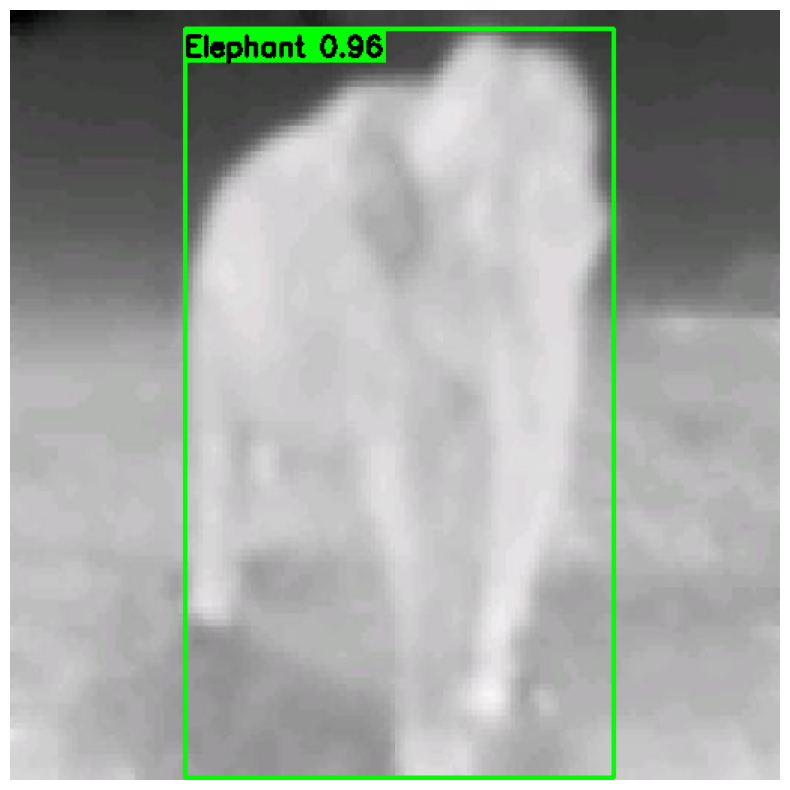

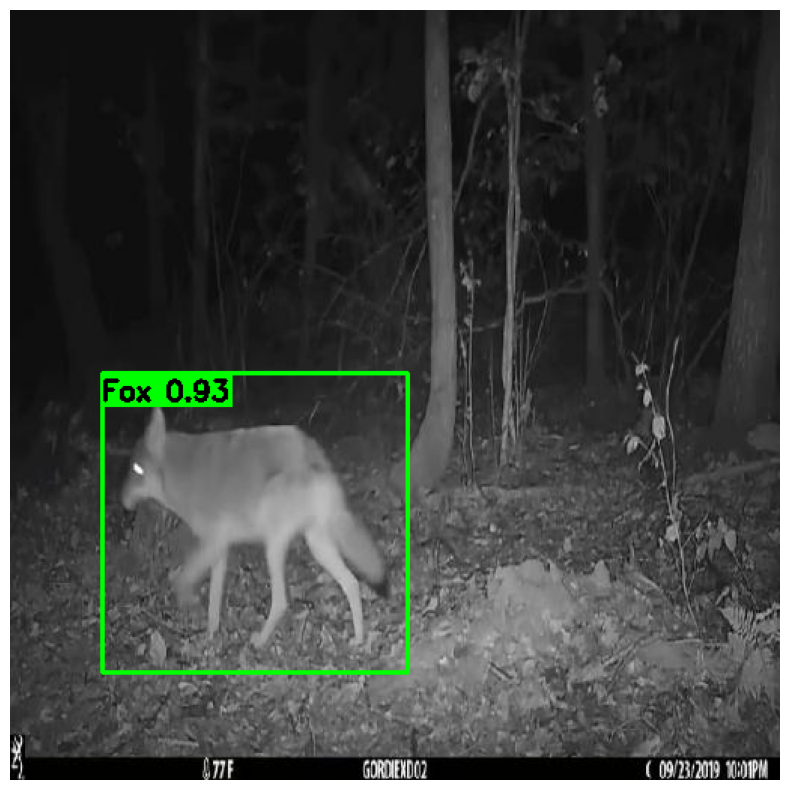

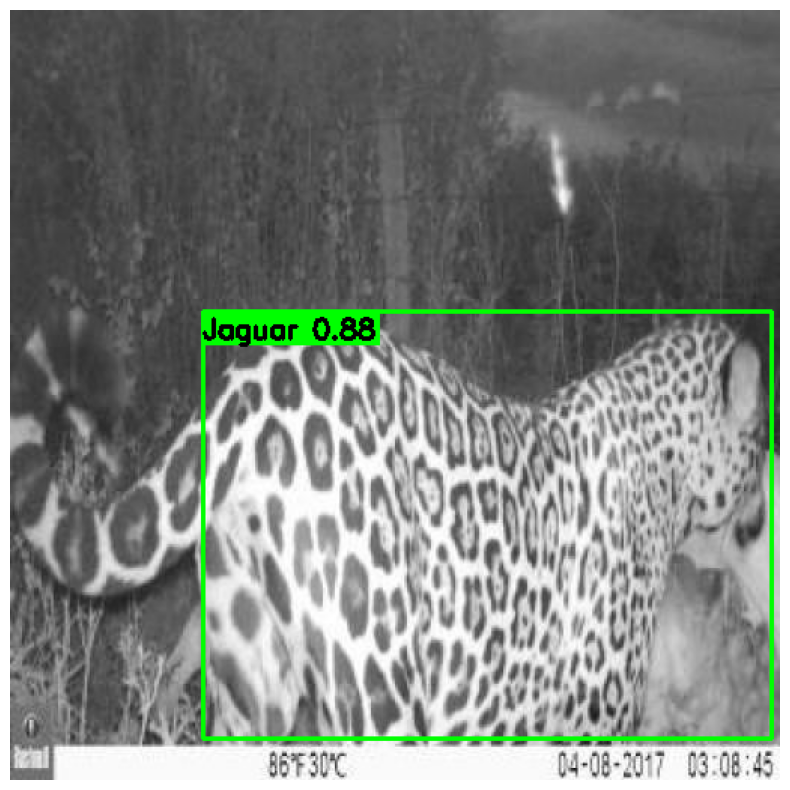

In [8]:
visualize(r"C:\Users\kbdpa.TRIVEDI\JC-Kavilesw-2b99\newDataset\nm\hybrid_final\My-First-Project-2\test\images\00001_result_30_png_jpg.rf.e32beeb4fd71a415bd50801fb1cdf559.jpg")
visualize(r"C:\Users\kbdpa.TRIVEDI\JC-Kavilesw-2b99\newDataset\nm\hybrid_final\My-First-Project-2\test\images\WhatsApp-Video-2024-02-14-at-5_05_03-PM_mp4-0428_jpg.rf.110095a13bb71a1f8b620d47340f9588.jpg")
visualize(r"C:\Users\kbdpa.TRIVEDI\JC-Kavilesw-2b99\newDataset\nm\hybrid_final\My-First-Project-2\test\images\video_PM8400061-MP4_imagem_10_jpg.rf.d5d13dbae41235e9f0cca4cb92e43d45.jpg")

In [9]:
def evaluate_hybrid(test_images, test_labels):

    y_true = []
    y_pred = []

    for img_file in os.listdir(test_images):

        image_path = os.path.join(test_images, img_file)
        label_path = os.path.join(test_labels, img_file.replace(".jpg", ".txt"))

        if not os.path.exists(label_path):
            continue

        with open(label_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            continue

        boxes, scores, labels = hybrid_predict(image_path)

        pred_label = labels[0] if len(labels) > 0 else -1

        for line in lines:
            parts = line.strip().split()
            if len(parts) == 0:
                continue

            true_label = int(parts[0])

            y_true.append(true_label)
            y_pred.append(pred_label)

    return y_true, y_pred

In [10]:
from sklearn.metrics import confusion_matrix

test_images = r"C:/Users/kbdpa.TRIVEDI/JC-Kavilesw-2b99/newDataset/nm/hybrid_final/My-First-Project-2/test/images"
test_labels = r"C:/Users/kbdpa.TRIVEDI/JC-Kavilesw-2b99/newDataset/nm/hybrid_final/My-First-Project-2/test/labels"

y_true, y_pred = evaluate_hybrid(test_images, test_labels)

print("Total samples:", len(y_true))



0: 640x640 2 Cheetahs, 318.7ms
Speed: 27.7ms preprocess, 318.7ms inference, 14.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Leopards, 137.6ms
Speed: 5.9ms preprocess, 137.6ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 138.1ms
Speed: 5.2ms preprocess, 138.1ms inference, 6.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 137.9ms
Speed: 5.9ms preprocess, 137.9ms inference, 7.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 138.4ms
Speed: 7.1ms preprocess, 138.4ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 138.4ms
Speed: 7.2ms preprocess, 138.4ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 137.7ms
Speed: 6.6ms preprocess, 137.7ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Hyena, 138.3ms
Speed: 6.1ms preprocess, 138.3ms inference, 3.4ms postprocess per image at

In [11]:
cm = confusion_matrix(y_true, y_pred)

precision_per_class = np.diag(cm) / (np.sum(cm, axis=0) + 1e-9)
recall_per_class = np.diag(cm) / (np.sum(cm, axis=1) + 1e-9)

precision = np.mean(precision_per_class)
recall = np.mean(recall_per_class)

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

map50 = precision

print("Precision :", round(precision,3))
print("Recall :", round(recall,3))
print("F1 Score :", round(f1,3))
print("mAP@0.5 :", round(map50,3))

Precision : 0.858
Recall : 0.853
F1 Score : 0.855
mAP@0.5 : 0.858
